# Plant-Soil-Microbe interactions with EcoSIM

EcoSIM is an advanced simulation framework for the realistic portrayal of plant-soil-microbe interactions across scales that can be used for a wide range of land modeling applications. EcoSIM has functional modules for

* Ecohydrology (Vegetation traits, Multilayer radiation, Photosynthesis, Canopy energy balance, Dynamic allocation, Dynamic shoot growth, and Dynamic root growth)
* Microbiology (Microbial traits such as Size, shape, surface area (constraints uptake), Cell stoichiometry, $\mu_{\text{max}}, T_{\text{opt}}$, and Symbionts such as Mycorrhizae, Diazotrophs)
* Biogeochemistry (Bacterial heterotrophs - fungal saprotrophs, Nitrate reduction, N fixation, Ammonia - nitrite oxidation, Fermentation, Methanogenesis, Methane oxidation)
* Geology/Geochemistry (Organo-mineral interactions, Aqueous chemistry, Salinity, Erosion)
* Disturbance and management (Wildfire - insects, Ecosystem management, Agriculture, Forestry)

We are taking a phased approach to couple EcoSIM to ATS as a PK that will use EcoSIM process models to compute their contributions to the appropriate ATS conservation equations. In the current phase, the coupling allows for the calculation of ET, capturing also the snow dyamics, via a prescribed phenology approach (i.e. plant growth is not included).  

This set of simulations demonstrates the current set of capabilities.

* **snow dynamics** by varying controlling parameters

Authors: Andrew Graus (code, demos) and Sergi Molins (demos documentation)

In [2]:
%matplotlib inline

In [1]:
import sys,os
sys.path.append(os.path.join(os.environ['ATS_SRC_DIR'],'tools', 'utils'))
sys.path.append(os.path.join(os.environ['ATS_SRC_DIR'],'docs', 'documentation', 'source', 'ats_demos'))

#import ats_xdmf
#import colors
#import numpy as np
from matplotlib import pyplot as plt
#from matplotlib import colorbar
import pandas
#import run_demos

#import h5py

## Snow dynamics: Albedo options

These three examples show how one can control the albedo in EcoSIM, which results in different evolutions of the snow depth:

- A relatively low albedo value is provided in the ATS input file and passed to EcoSIM (albedo = 0.3)
- A relatively high albedo value is provided in the ATS input file and passed to EcoSIM (albedo = 0.9)
- No albedo value is provided in the ATS input file, thus letting EcoSIM use its internal albedo values: 
```xml
<Parameter name="Prescribe Albedo" type="bool" value="false" />
```

In what follows, we plot the evolution of the snow depth with time over the 5-year simulation: 

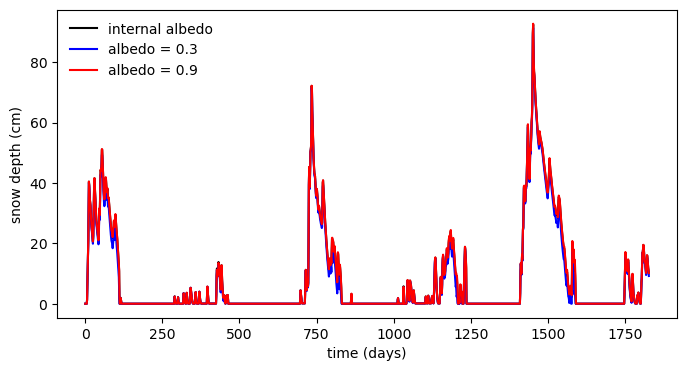

In [5]:
dir_no_albedo = "snow_dynamics_albedo_internal.demo"
dir_lo_albedo = "snow_dynamics_albedo_low.demo"
dir_hi_albedo = "snow_dynamics_albedo_high.demo"

no_albedo = pandas.read_csv(os.path.join(dir_no_albedo, 'snow_status.dat'), comment='#')
lo_albedo = pandas.read_csv(os.path.join(dir_lo_albedo, 'snow_status.dat'), comment='#')
hi_albedo = pandas.read_csv(os.path.join(dir_hi_albedo, 'snow_status.dat'), comment='#')

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.plot(no_albedo['time [s]'][:]/86400, no_albedo['snow_depth'][:]*100., color='k', label="internal albedo")
ax.plot(lo_albedo['time [s]'][:]/86400, lo_albedo['snow_depth'][:]*100., color='b', label="albedo = 0.3")
ax.plot(hi_albedo['time [s]'][:]/86400, hi_albedo['snow_depth'][:]*100., color='r', label="albedo = 0.9")

ax.set_xlabel("time (days)")
ax.set_ylabel("snow depth (cm)")
ax.legend(frameon=False)
plt.show()

The differences are small and better seen in specific periods of the year. We zoom into these periods:

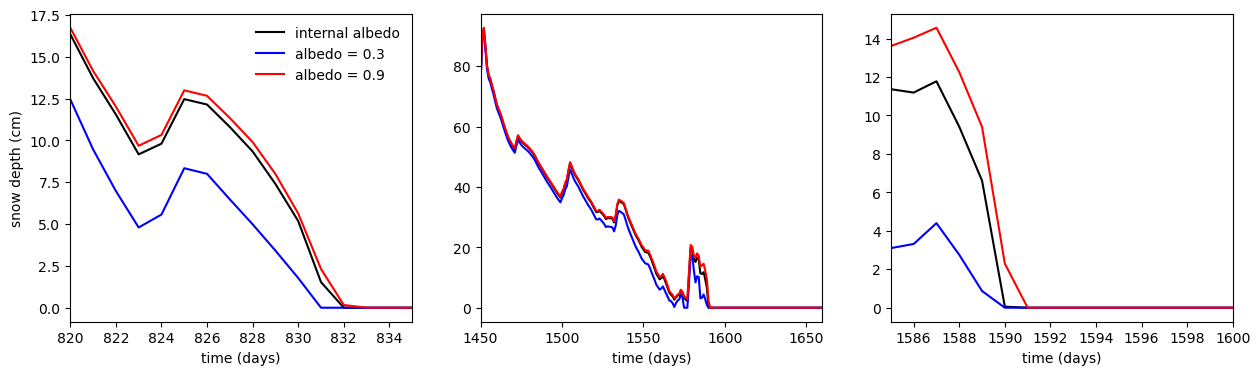

In [4]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

# periods of interest
periods = [(820, 835), (1450, 1660), (1585, 1600)]

for i, (t1, t2) in enumerate(periods):
    # Slice data for this period to ensure y-axis autoscales correctly
    mask_no = (no_albedo['time [s]']/86400 >= t1) & (no_albedo['time [s]']/86400 <= t2)
    mask_lo = (lo_albedo['time [s]']/86400 >= t1) & (lo_albedo['time [s]']/86400 <= t2)
    mask_hi = (hi_albedo['time [s]']/86400 >= t1) & (hi_albedo['time [s]']/86400 <= t2)

    ax[i].plot(no_albedo['time [s]'][mask_no]/86400, no_albedo['snow_depth'][mask_no]*100., color='k', label="internal albedo")
    ax[i].plot(lo_albedo['time [s]'][mask_lo]/86400, lo_albedo['snow_depth'][mask_lo]*100., color='b', label="albedo = 0.3")
    ax[i].plot(hi_albedo['time [s]'][mask_hi]/86400, hi_albedo['snow_depth'][mask_hi]*100., color='r', label="albedo = 0.9")

    ax[i].set_xlabel("time (days)")
    ax[i].set_xlim(t1, t2)

ax[0].set_ylabel("snow depth (cm)")
ax[0].legend(frameon=False)
plt.show()